# Turning line-ups into numbers

A model cannot read `('breach', 'cypher', 'neon', 'omen', 'sova')`. It needs numbers.
This notebook works out how to describe a team's five agents as numbers without throwing
away what matters, and then checks honestly whether the agents alone tell us much at all.

The short version of what we find: **individual agents barely predict anything.** That is
a genuinely useful result and it shapes what we do next.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent / "src"))

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 40)
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

from dataset import build_map_table
from features import agent_list, build_features, swap_teams

maps = build_map_table()
print(f"{len(maps):,} maps")

1,272 maps


## 1. Why we can't just use the line-up as it is

The obvious idea is to treat each five-agent line-up as a single thing and ask "how often
does this line-up win?". Here is why that fails.

In [2]:
all_lineups = pd.concat([maps["comp_a"], maps["comp_b"]])
counts = all_lineups.value_counts()

print(f"line-ups played        : {len(all_lineups):,}")
print(f"different line-ups     : {len(counts):,}")
print(f"used only once         : {(counts == 1).sum():,}  ({(counts == 1).mean():.0%} of them)")
print(f"used 5 times or fewer  : {(counts <= 5).sum():,}  ({(counts <= 5).mean():.0%} of them)")
print()
print("The most-used line-up, and how often it appeared:")
print(f"   {counts.index[0]}  ->  {counts.iloc[0]} times")

line-ups played        : 2,544
different line-ups     : 459
used only once         : 162  (35% of them)
used 5 times or fewer  : 354  (77% of them)

The most-used line-up, and how often it appeared:
   ('fade', 'omen', 'raze', 'viper', 'vyse')  ->  86 times


Most line-ups appear a handful of times, and hundreds appear exactly once. A model given
these as separate categories would be trying to learn from a single example in most cases,
which is impossible. Worse, when it met a new line-up it had never seen, it would have
nothing to go on at all — even if that line-up shared four of its five agents with one it
knew well.

The fix is to stop treating a line-up as one indivisible thing and describe it by **which
agents are in it**. Then a line-up sharing four agents with another looks nearly the same,
which is much closer to the truth.

## 2. How we describe a map

Which team is called A and which is called B is just the order they happen to be listed in.
It means nothing. So rather than describing the two teams separately, we describe the
**difference** between them, from team A's side:

| Value | Meaning |
|---|---|
| `+1` | only team A played this agent |
| `-1` | only team B played this agent |
| `0` | both teams played them, or neither did |

Agents that both teams played become zero deliberately. If both sides played Omen, Omen
cannot be the reason one of them won. This happens a lot — teams share about three of
their five agents on a typical map.

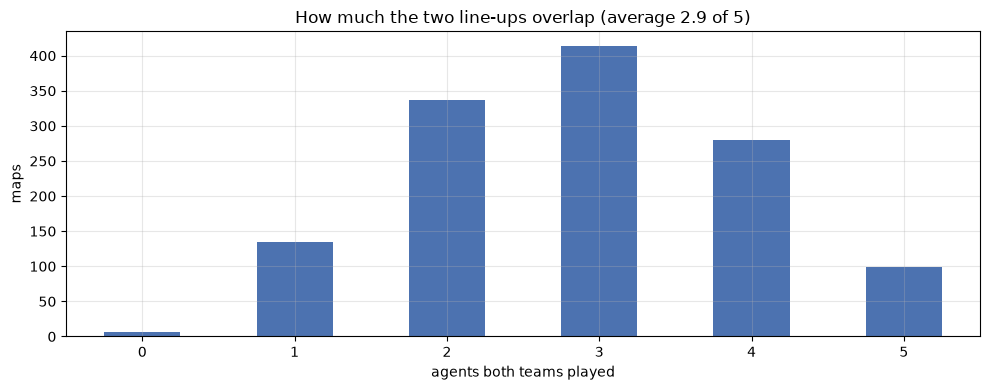

In [3]:
shared = pd.Series([len(set(a) & set(b)) for a, b in zip(maps["comp_a"], maps["comp_b"])])

ax = shared.value_counts().sort_index().plot.bar(color="#4c72b0")
ax.set_xlabel("agents both teams played")
ax.set_ylabel("maps")
ax.set_title(f"How much the two line-ups overlap (average {shared.mean():.1f} of 5)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

On 99 maps the two teams played **identical** line-ups. On those, the agents tell us
literally nothing about who wins — which is a useful reminder of the ceiling on what
agent choices alone can ever explain.

## 3. Building it

In [4]:
X, y = build_features(maps)

print(f"{X.shape[0]:,} maps described by {X.shape[1]} numbers each")
print()
print(f"  {len(agent_list(maps))} agent comparisons")
print(f"  {maps['map'].nunique()} columns saying which map was played")
print(f"  1 column saying who chose the map")
print()
print(f"missing values: {X.isna().sum().sum()}")
X.head()

1,272 maps described by 39 numbers each

  27 agent comparisons
  11 columns saying which map was played
  1 column saying who chose the map

missing values: 0


,agent_astra,agent_breach,agent_brimstone,agent_chamber,agent_clove,agent_cypher,agent_deadlock,agent_fade,agent_gekko,agent_harbor,agent_iso,agent_jett,agent_kayo,agent_killjoy,agent_neon,agent_omen,agent_phoenix,agent_raze,agent_reyna,agent_sage,agent_skye,agent_sova,agent_tejo,agent_viper,agent_vyse,agent_waylay,agent_yoru,map_Abyss,map_Ascent,map_Bind,map_Corrode,map_Fracture,map_Haven,map_Icebox,map_Lotus,map_Pearl,map_Split,map_Sunset,map_picked_by_a
0,0,0,0,0,0,0,0,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,-1
1,1,0,0,0,0,-1,0,0,0,0,0,0,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1
2,0,0,0,0,0,1,0,-1,0,0,0,0,0,0,1,0,0,-1,0,0,0,1,0,0,-1,0,0,0,0,0,0,0,0,0,1,0,0,0,1
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,-1,0,0,0,0,0,0,0,0,0,0,0,1,0,-1
4,0,0,0,0,0,0,0,0,0,0,0,0,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1


Everything here is known **before the map is played**, which is the whole point. Anything
recorded during the map — kills, damage, scores — would tell the model how the map went,
so it would predict brilliantly in testing and be useless in real life, because you would
never have those numbers in advance.

## 4. Checking it behaves sensibly

Here is a test with a clear right answer. If we swap the two teams round — call team B
"team A" and vice versa — then every comparison should flip to its opposite, and the
winner should flip too. The map that was played should not change, because swapping the
teams does not change which map they were on.

If this fails, the numbers are being built wrongly somewhere.

In [5]:
X_swapped, y_swapped = build_features(swap_teams(maps))

should_flip = [c for c in X.columns if c.startswith("agent_")] + ["map_picked_by_a"]
should_stay = [c for c in X.columns if c.startswith("map_") and c != "map_picked_by_a"]

print(f"agent comparisons and map choice flip : {(X_swapped[should_flip] == -X[should_flip]).all().all()}")
print(f"which map was played stays the same   : {(X_swapped[should_stay] == X[should_stay]).all().all()}")
print(f"the winner flips                      : {(y_swapped == 1 - y).all()}")

agent comparisons and map choice flip : True
which map was played stays the same   : True
the winner flips                      : True


In [6]:
agent_cols = [c for c in X.columns if c.startswith("agent_")]
non_zero = (X[agent_cols] != 0).sum(axis=1)

print(f"on an average map, {non_zero.mean():.1f} of the {len(agent_cols)} agent comparisons are not zero")
print(f"the rest are agents both teams played, or neither did")
print()
print(f"maps where the line-ups were identical (nothing to compare): {(non_zero == 0).sum()}")

on an average map, 4.2 of the 27 agent comparisons are not zero
the rest are agents both teams played, or neither did

maps where the line-ups were identical (nothing to compare): 99


## 5. The honest question: does any single agent actually help you win?

Now that we can ask it cleanly, we should. For each agent we look only at maps where
**one team had them and the other did not** — those are the only maps where that agent
could have made a difference — and ask how often the team with them won.

The catch is that a win rate measured over a small number of maps bounces around by pure
chance. So alongside each number we work out how far it could stray from 50% on luck
alone. Anything inside that range is not evidence of anything.

In [7]:
rows = []
for agent in agent_list(maps):
    only_a = maps["comp_a"].map(lambda c, a=agent: a in c) & ~maps["comp_b"].map(lambda c, a=agent: a in c)
    only_b = maps["comp_b"].map(lambda c, a=agent: a in c) & ~maps["comp_a"].map(lambda c, a=agent: a in c)

    decisive_maps = int(only_a.sum() + only_b.sum())
    wins = int(maps.loc[only_a, "team_a_won"].sum() + (1 - maps.loc[only_b, "team_a_won"]).sum())

    win_rate = 100 * wins / decisive_maps
    # How far a 50/50 coin would typically stray over this many maps.
    luck_range = 100 * 1.96 * np.sqrt(0.25 / decisive_maps)

    rows.append(
        {
            "agent": agent,
            "maps where only one side had them": decisive_maps,
            "win rate %": round(win_rate, 1),
            "luck could explain ±": round(luck_range, 1),
            "beyond luck?": abs(win_rate - 50) > luck_range,
        }
    )

agent_effects = pd.DataFrame(rows).sort_values("win rate %", ascending=False)
agent_effects.reset_index(drop=True)

,agent,maps where only one side had them,win rate %,luck could explain ±,beyond luck?
0,sage,77,57.1,11.2,False
1,chamber,110,56.4,9.3,False
2,phoenix,27,55.6,18.9,False
3,viper,329,54.4,5.4,False
4,raze,258,53.9,6.1,False
5,harbor,52,53.8,13.6,False
6,vyse,377,52.5,5.0,False
7,yoru,496,52.2,4.4,False
8,killjoy,205,51.7,6.8,False
9,tejo,336,51.5,5.3,False


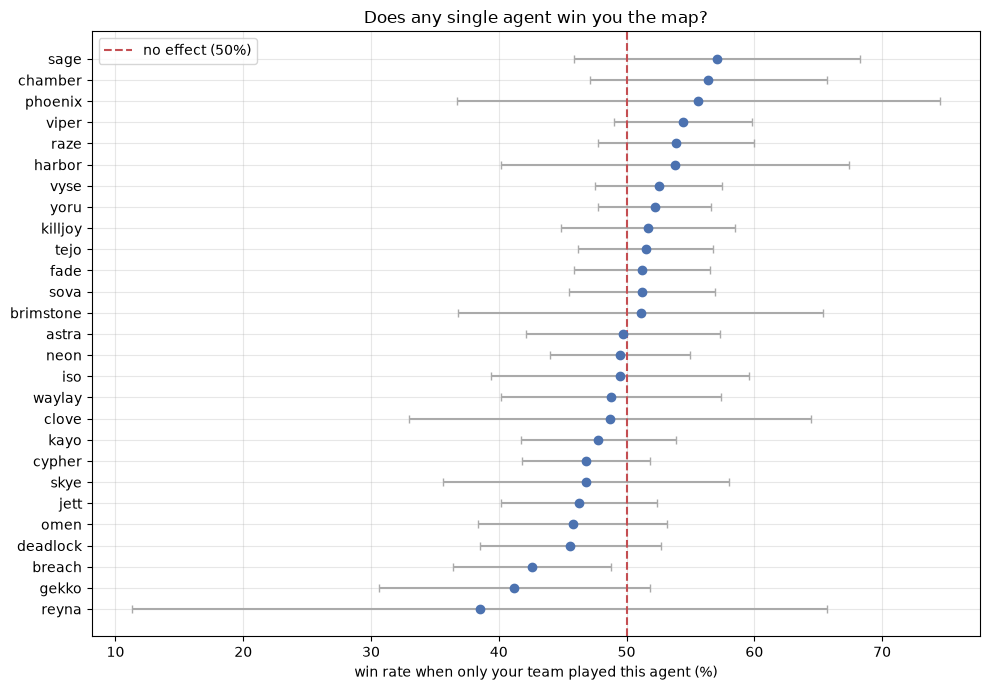

agents whose win rate is further from 50% than luck explains: 1 out of 27


In [8]:
plot_data = agent_effects.sort_values("win rate %")

fig, ax = plt.subplots(figsize=(10, 7))
ax.errorbar(
    plot_data["win rate %"],
    range(len(plot_data)),
    xerr=plot_data["luck could explain ±"],
    fmt="o",
    color="#4c72b0",
    ecolor="#aaaaaa",
    capsize=3,
)
ax.set_yticks(range(len(plot_data)))
ax.set_yticklabels(plot_data["agent"])
ax.axvline(50, color="#c44e52", linestyle="--", label="no effect (50%)")
ax.set_xlabel("win rate when only your team played this agent (%)")
ax.set_title("Does any single agent win you the map?")
ax.legend()
plt.tight_layout()
plt.show()

print(f"agents whose win rate is further from 50% than luck explains: "
      f"{agent_effects['beyond luck?'].sum()} out of {len(agent_effects)}")

**Almost every grey bar crosses the red line.** For nearly every agent, the win rate is
close enough to 50% that chance alone explains it.

One agent does fall outside the range — but that needs care rather than excitement. We
checked 27 agents. When you run 27 separate checks, roughly one of them landing outside a
"1-in-20" range is *exactly* what you would expect from luck, even if no agent made any
difference whatsoever. So this is not evidence that agent is bad; it is what a table of
27 coin-flip experiments looks like.

### What this means for the project

This is a real finding and it should go in the write-up. **Which agents a team picks, taken
one at a time, tells you almost nothing about who wins a map at this level.** That makes
sense: these are the best teams in the world, and they do not pick badly. Nobody is
fielding an agent that loses them four games in ten.

So if agent choices matter at all, it must be through one of:

1. **Combinations** — agents working together, which is the synergy half of this project
   and is not captured by looking at agents one at a time.
2. **Agents on specific maps** — Viper on Icebox may be a different proposition from
   Viper on Ascent.
3. **Who is playing them** — team strength, which has nothing to do with agents at all
   and is probably the biggest factor of the three.

It also sets an honest expectation. A model built on agent picks alone should not be
expected to do much better than a coin flip. If it suddenly scores 90%, something has
gone wrong and we should go looking for the mistake rather than celebrating.

## 6. Splitting the season, ready for modelling

Same split as before: learn from everything up to Masters Toronto, test on what came after.

In [9]:
SPLIT_DATE = pd.Timestamp("2025-06-23")
is_early = maps["played_at"] < SPLIT_DATE

X_learn, y_learn = X[is_early], y[is_early]
X_test, y_test = X[~is_early], y[~is_early]

print(f"learn from : {X_learn.shape[0]:,} maps, {X_learn.shape[1]} numbers each")
print(f"test on    : {X_test.shape[0]:,} maps")
print()
print(f"team A won {y_learn.mean():.1%} of the learning maps")
print(f"team A won {y_test.mean():.1%} of the testing maps")
print()
print("Both close to half, so the two halves are comparable and")
print("always guessing 'team A' scores about 50% on either.")

learn from : 756 maps, 39 numbers each
test on    : 516 maps

team A won 50.3% of the learning maps
team A won 52.3% of the testing maps

Both close to half, so the two halves are comparable and
always guessing 'team A' scores about 50% on either.


## 7. Where we are

Every map is now described by 39 numbers, all of them known before the map starts, and the
description behaves correctly when the two teams are swapped round.

What we learned:

- Treating each five-agent line-up as its own category would not work — 465 different
  line-ups, a third of them used once.
- Teams share about three of their five agents, so most of a line-up cancels out and only
  about four agent differences actually separate the two sides on a typical map.
- On 99 maps the two line-ups were identical, so agents cannot explain those results at all.
- No single agent has a win rate that stands apart from chance.

**Next:** fit the first model on these numbers. Expect it to be close to a coin flip —
that is the honest result given the above, and it becomes the baseline that later work
(agent combinations, agent-and-map together, team strength) has to beat.